<a href="https://colab.research.google.com/github/makkergauri/uttarakhand-landslide-risk/blob/main/01_build_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %% Setup
# colab already has earthengine-api, just need geemap for the maps
!pip install -q geemap

import ee

PROJECT_ID = "landslide-uttarakhand78873"  # my earth engine project id goes here
ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.2 MB/s eta 0:00:00


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [3]:
# %% Study area - Rudraprayag district
# switched to GAUL 2025 since the 2015 version is deprecated
# searching for "Rudra" instead of the exact name in case the spelling differs
districts = ee.FeatureCollection("FAO/GAUL/2025/level2")
match = (districts
         .filter(ee.Filter.eq("ISO3_CODE", "IND"))
         .filter(ee.Filter.stringContains("GAUL2_NAME", "Rudra")))

print("Matches found:", match.aggregate_array("GAUL2_NAME").getInfo())

if match.size().getInfo() > 0:
    aoi = match.geometry()
    print("Using official Rudraprayag boundary")
else:
    aoi = ee.Geometry.Rectangle([78.8, 30.2, 79.4, 30.8])
    print("District not found, using approx bounding box")

# %% Terrain - slope is the main factor, steeper ground = more likely to slide
# aspect = which direction the slope faces, affects sunlight + moisture
dem = ee.Image("USGS/SRTMGL1_003").clip(aoi)
elevation = dem.rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")
aspect = ee.Terrain.aspect(dem).rename("aspect")

# %% Vegetation (NDVI) - roots hold the soil together so bare slopes are weaker
# using Oct-Mar because monsoon images are basically all clouds
ndvi = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2024-10-01", "2025-03-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .median()
    .normalizedDifference(["B8", "B4"])  # NDVI = (NIR - Red) / (NIR + Red)
    .rename("ndvi")
    .clip(aoi)
)

# %% Land cover - forest vs farmland vs built-up vs bare rock
landcover = ee.ImageCollection("ESA/WorldCover/v200").first().rename("landcover").clip(aoi)

# %% Distance to rivers - rivers erode the bottom of slopes which makes them unstable
rivers = ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers").filterBounds(aoi.buffer(20000))
dist_river = rivers.distance(searchRadius=20000).rename("dist_river").clip(aoi)

# %% Stack everything into one image
features = ee.Image.cat([elevation, slope, aspect, ndvi, landcover, dist_river])
print("Bands:", features.bandNames().getInfo())

Matches found: ['Rudraprayag']
Using official Rudraprayag boundary
Bands: ['elevation', 'slope', 'aspect', 'ndvi', 'landcover', 'dist_river']


In [5]:
# %% Quick look at the layers
# OpenStreetMap tiles were getting blocked in Colab, so using satellite imagery as the background
import geemap

m = geemap.Map(basemap="HYBRID")
m.setCenter(79.1, 30.5, 10)  # lon, lat, zoom - centred on Rudraprayag

# only slope is switched on at first, turn the others on from the layers button
m.addLayer(slope, {"min": 0, "max": 60, "palette": ["white", "yellow", "red"]}, "Slope", True, 0.8)
m.addLayer(ndvi, {"min": 0, "max": 0.8, "palette": ["brown", "yellow", "green"]}, "NDVI", False)
m.addLayer(dist_river, {"min": 0, "max": 5000, "palette": ["blue", "white"]}, "Dist. to river", False)
m.addLayer(ee.Image().paint(aoi, 0, 2), {"palette": ["black"]}, "Study area")
m

Map(center=[30.5, 79.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [6]:
# %% Export the full feature stack to Google Drive (need this for step 2)
# EPSG:32644 = UTM zone 44N, which covers Uttarakhand, units in metres
task = ee.batch.Export.image.toDrive(
    image=features.toFloat(),
    description="rudraprayag_features",
    folder="landslide_project",
    region=aoi,
    scale=30,
    crs="EPSG:32644",
    maxPixels=1e10,
)
task.start()
print("Export started - it goes to my Google Drive, takes 5-20 min")

Export started - it goes to my Google Drive, takes 5-20 min


In [7]:
# %% Mount Google Drive so I can read the exported feature stack
from google.colab import drive
drive.mount('/content/drive')

!pip install -q rasterio matplotlib-scalebar

Mounted at /content/drive


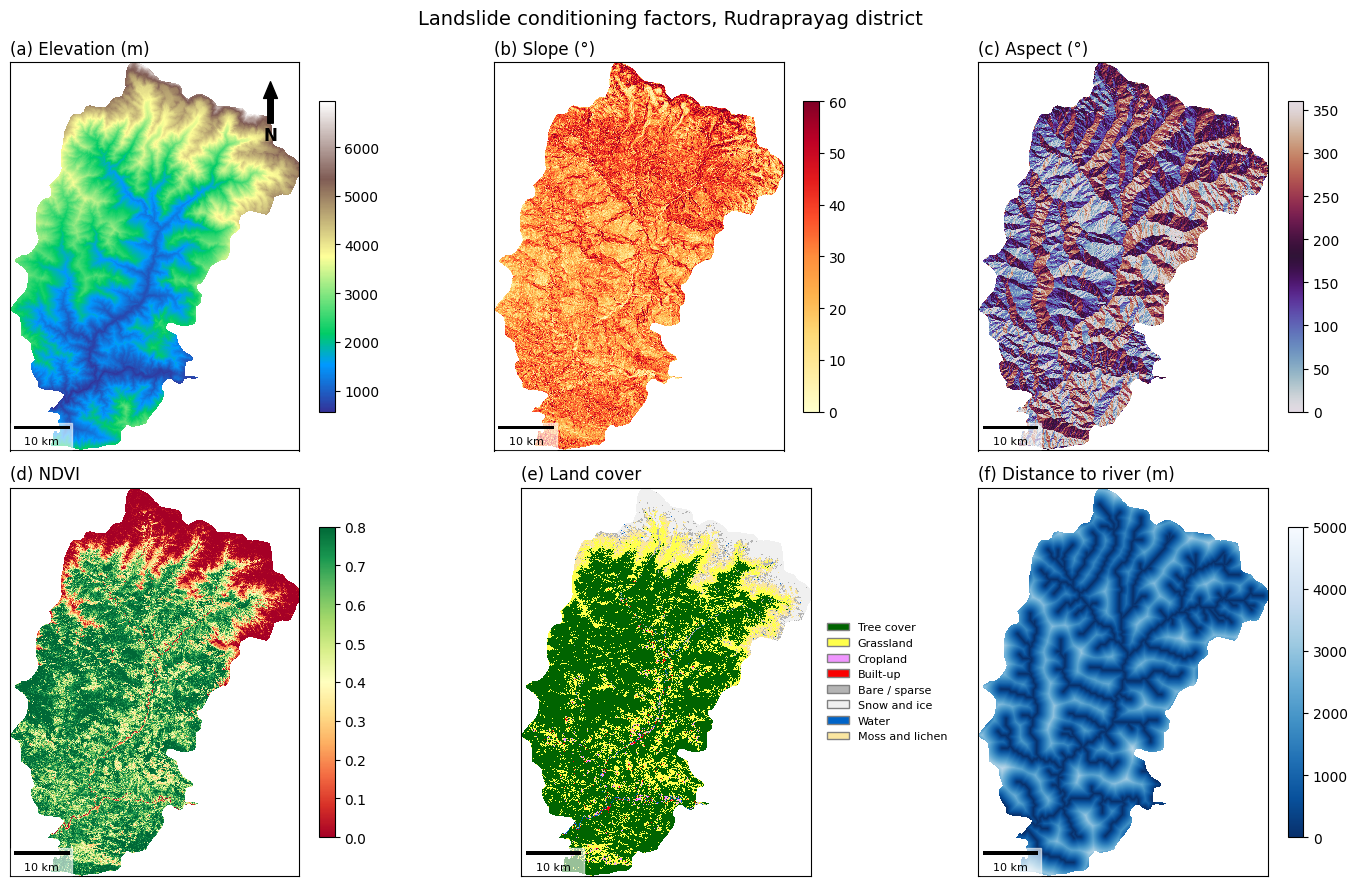

In [9]:
# %% Figure 2 - conditioning factors panel for the paper
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import plotting_extent
from matplotlib_scalebar.scalebar import ScaleBar

path = "/content/drive/MyDrive/landslide_project/rudraprayag_features.tif"

# reading at half resolution (60m) - plenty for a figure and much faster
with rasterio.open(path) as src:
    data = src.read(out_shape=(src.count, src.height // 2, src.width // 2)).astype(float)
    extent = plotting_extent(src)

# pixels outside the district come out as 0, masking them so they show as blank
outside = data[0] == 0
data[:, outside] = np.nan

# band order is the same as in my ee.Image.cat() call
panels = [
    (0, "(a) Elevation (m)",              "terrain",  None, None),
    (1, "(b) Slope (°)",                  "YlOrRd",   0,    60),
    (2, "(c) Aspect (°)",                 "twilight", 0,    360),  # cyclic colormap since 0° = 360°
    (3, "(d) NDVI",                       "RdYlGn",   0,    0.8),
    (4, "(e) Land cover (ESA class)",     "tab10",    10,   100),
    (5, "(f) Distance to river (m)",      "Blues_r",  0,    5000),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# official ESA WorldCover class names + colours, so the land cover panel gets a proper legend
wc_classes = {
    10: ("Tree cover", "#006400"),   20: ("Shrubland", "#ffbb22"),
    30: ("Grassland", "#ffff4c"),    40: ("Cropland", "#f096ff"),
    50: ("Built-up", "#fa0000"),     60: ("Bare / sparse", "#b4b4b4"),
    70: ("Snow and ice", "#f0f0f0"), 80: ("Water", "#0064c8"),
    90: ("Wetland", "#0096a0"),      100: ("Moss and lichen", "#fae6a0"),
}

for ax, (band, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    if band == 4:
        # land cover is categorical, so a legend instead of a colorbar
        present = [c for c in wc_classes if np.any(data[4] == c)]  # only classes that exist here
        idx = np.full(data[4].shape, np.nan)
        for i, c in enumerate(present):
            idx[data[4] == c] = i
        lc_cmap = ListedColormap([wc_classes[c][1] for c in present])
        ax.imshow(idx, cmap=lc_cmap, vmin=-0.5, vmax=len(present) - 0.5,
                  extent=extent, interpolation="nearest")
        handles = [mpatches.Patch(facecolor=wc_classes[c][1], edgecolor="grey", label=wc_classes[c][0])
                   for c in present]
        ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
                  fontsize=8, frameon=False)
        title = "(e) Land cover"
    else:
        im = ax.imshow(data[band], cmap=cmap, vmin=vmin, vmax=vmax,
                       extent=extent, interpolation="nearest")
        fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_xticks([]); ax.set_yticks([])
    # data is in UTM so 1 unit = 1 metre, which the scale bar needs
    ax.add_artist(ScaleBar(1, location="lower left", box_alpha=0.6, font_properties={"size": 8}))

# north arrow on the first panel only
axes.flat[0].annotate("N", xy=(0.9, 0.95), xytext=(0.9, 0.8), xycoords="axes fraction",
                      ha="center", fontsize=12, fontweight="bold",
                      arrowprops=dict(facecolor="black", width=4, headwidth=10))

fig.suptitle("Landslide conditioning factors, Rudraprayag district", fontsize=14)
plt.tight_layout()

# saving both PNG (for github/twitter) and PDF (for the paper, stays sharp when zoomed)
out_dir = "/content/drive/MyDrive/landslide_project/figures"
os.makedirs(out_dir, exist_ok=True)
fig.savefig(f"{out_dir}/fig2_conditioning_factors.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{out_dir}/fig2_conditioning_factors.pdf", bbox_inches="tight")
plt.show()